In [1]:
import pandas as pd
import os

# --- 1. CONFIGURATION ---
# Define groups and their respective files
data_groups = [
    {'id': 'g1', 
     's1': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g1_s1_meta_enc.csv', 
     's2': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g1_s2_meta_enc.csv'},
    {'id': 'g2', 
     's1': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g2_s1_meta_enc.csv', 
     's2': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g2_s2_meta_enc.csv'},
    {'id': 'g3', 
     's1': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g3_s1_meta_enc.csv', 
     's2': '/home/ist-seminar/Documents/data/20251027/pose_20251027_g3_s2_meta_enc.csv'}
]

# Output directory
output_dir = '/home/ist-seminar/Documents/data/20251027/'

# --- 2. PROCESSING ---
for group in data_groups:
    # Load S1 and S2
    df_s1 = pd.read_csv(group['s1'])
    df_s2 = pd.read_csv(group['s2'])
    
    # Merge on 'time' column with suffixes to distinguish participants
    df_merged = pd.merge(df_s1, df_s2, on='time', suffixes=('_s1', '_s2'))
    
    # Save the merged CSV
    out_name = f"pose_20251027_{group['id']}_merged.csv"
    df_merged.to_csv(os.path.join(output_dir, out_name), index=False)
    
    # Simple status check
    print(f"Group {group['id']} processed. Rows: {len(df_merged)}")

Group g1 processed. Rows: 40593
Group g2 processed. Rows: 37968
Group g3 processed. Rows: 36663


In [2]:
import pympi
import numpy as np
from scipy.signal import find_peaks
import glob

all_samples = []
merged_files = glob.glob(os.path.join(output_dir, 'pose_20251027_g*_merged.csv'))

for csv_path in merged_files:
    df = pd.read_csv(csv_path)
    group_id = csv_path.split('_')[-2]
    
    # Bias correction: medians as neutral baseline
    medians = {c: df[c].median() for c in ['yaw_s1', 'yaw_s2', 'pitch_s1', 'pitch_s2']}
    
    # EAF file path
    eaf_path = f'/home/ist-seminar/Documents/data/annotation/meta-segment/20251027_{group_id}_all_meta_combined.eaf'
    eaf = pympi.Eaf(eaf_path)
    
    for start, end, label in eaf.get_annotation_data_for_tier('meta-topic'):
        dur = (end - start) / 1000
        df_slice = df[(df['time'] >= start/1000) & (df['time'] <= end/1000)]
        
        if len(df_slice) > 5:
            # Features
            y1 = np.abs(df_slice['yaw_s1'] - medians['yaw_s1']).mean()
            y2 = np.abs(df_slice['yaw_s2'] - medians['yaw_s2']).mean()
            p1 = len(find_peaks(df_slice['pitch_s1'], prominence=1.0, distance=5)[0]) / dur
            p2 = len(find_peaks(df_slice['pitch_s2'], prominence=1.0, distance=5)[0]) / dur
            
            all_samples.append({
                'total_gaze_dev': y1 + y2,
                'avg_nod_rate': (p1 + p2) / 2,
                'label': label.split('/')[-1].strip()
            })

pd.DataFrame(all_samples).to_csv('samples.csv', index=False)
print("Samples saved to samples.csv")

Samples saved to samples.csv


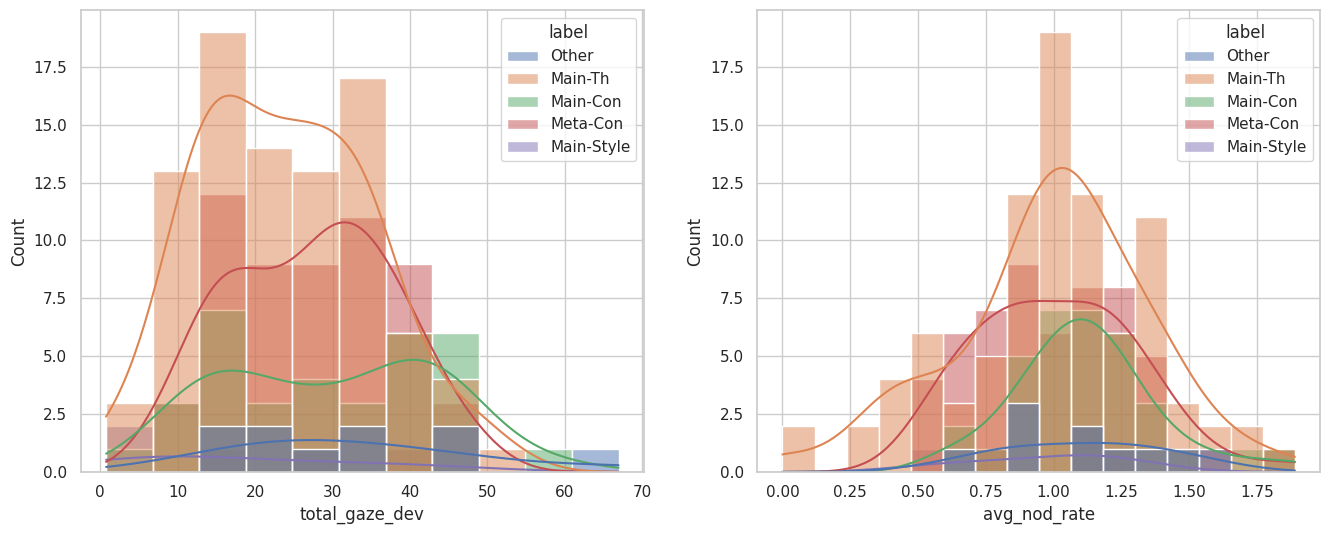

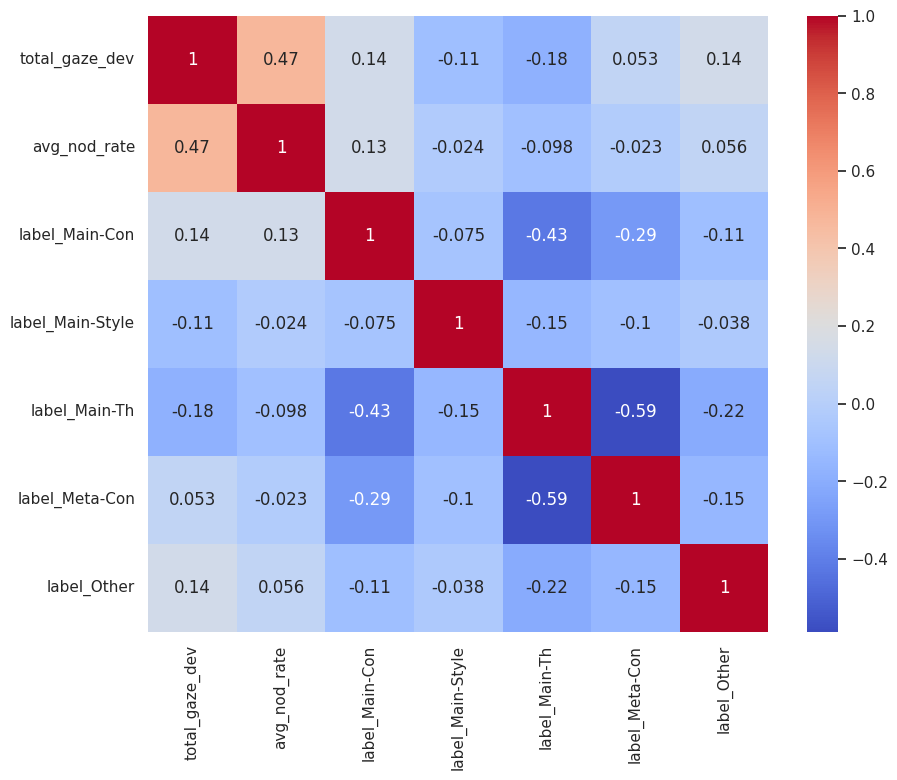

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('samples.csv')
sns.set_theme(style="whitegrid")

# Histograms
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1); sns.histplot(data=df, x='total_gaze_dev', hue='label', kde=True)
plt.subplot(1, 2, 2); sns.histplot(data=df, x='avg_nod_rate', hue='label', kde=True)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pd.get_dummies(df, columns=['label']).corr(), annot=True, cmap='coolwarm')
plt.show()